In [1]:
import polars as pl
import pandas as pd
from cryptorandom.cryptorandom import SHA256
from cryptorandom.sample import random_sample
from permute.core import two_sample
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats.contingency import odds_ratio
sns.set_theme(font="Times", font_scale=1.2)

import os
os.chdir('../')

# Data Description

This notebook serves to provide the descriptive data analysis that accompanies the statistical analysis in the other notebooks

 - distribution of filed vs pending
 - distribution of charges (attempt murder v other)
 - distribution of enhancement (enhancement v no enhancement)
 - distribution of prison (county, state)
 - distribution of dismissal
 - distribution of prison sentences 

In [2]:
def get_pct(df_counts, cond_col):
    pcts = df_counts.with_columns(pct = pl.lit(0.0)
    )
    for i in range(len(pcts)):
        cond = pcts[i, cond_col]
        race = pcts.item(i, "Race")
        count = pcts.item(i, "len")
        total = pcts.filter(pcts["Race"]==race)["len"].sum()
        pcts[i, "pct"] = round(count/total,3)*100
    return pcts

In [3]:
df = pl.read_csv("example-1/example_1_data_sanitized.csv").filter(
    (pl.col("Exclude?").fill_null(0) != 1),
    (pl.col("Someone shot? (0=no, 1=yes)") == 1 )
    ).with_columns(Prison = pl.col("State prison Prison?"))

In [4]:
df_closed = df.filter(pl.col("Open  = 0; Closed =1") == 1)

In [5]:
custom_palette = {
    "Yes": sns.color_palette()[0],
    "No": sns.color_palette()[1],
}
race_order = ["H", "W", "B", "A", "O"]
race_full_names = {"A":"Asian",
                   "B":"Black",
                   "W":"White",
                   "H":"Latino",
                   "O":"Other"}

Case Status,Race,len
str,str,u32
"""Closed""","""A""",3
"""Open""","""B""",10
"""Closed""","""B""",30
"""Closed""","""H""",19
"""Open""","""H""",5
"""Closed""","""O""",3
"""Closed""","""W""",16
"""Open""","""W""",1


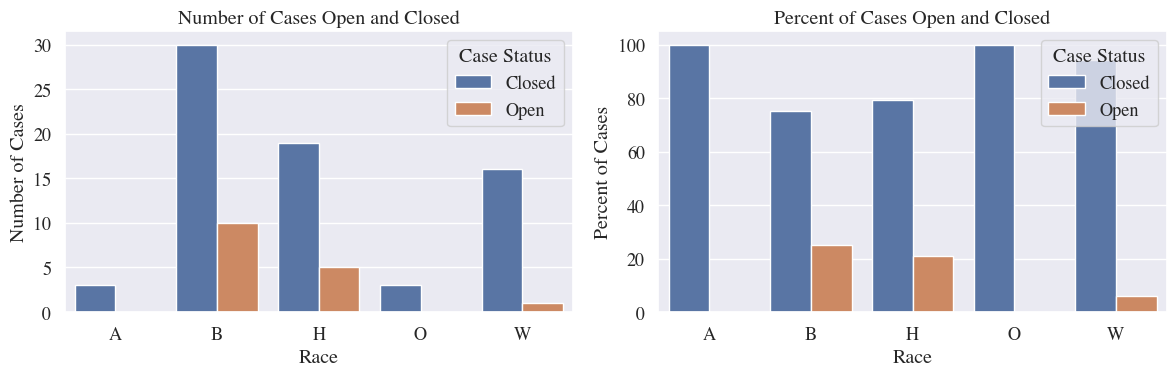

In [6]:
filed_pending = df.group_by(pl.col("Open  = 0; Closed =1", "Race")).len().with_columns(
    pl.when(pl.col("Open  = 0; Closed =1") == 1).then(pl.lit("Closed"))\
        .when(pl.col("Open  = 0; Closed =1") == 0).then(pl.lit("Open"))\
        .otherwise(pl.col("Open  = 0; Closed =1")).name.keep()
    ).sort("Race").rename({"Open  = 0; Closed =1": "Case Status"})
display(filed_pending)
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(filed_pending, x="Race", hue="Case Status", y="len", ax=ax[0])
barplot.set_ylabel("Number of Cases")
barplot.set_label("")
barplot.set_title("Number of Cases Open and Closed")
barplot1 = sns.barplot(get_pct(filed_pending,"Case Status"), x="Race", hue="Case Status", y="pct", ax=ax[1])
barplot1.set_ylabel("Percent of Cases")
barplot1.set_label("")
barplot1.set_title("Percent of Cases Open and Closed")
plt.tight_layout()
plt.savefig("case_status.pdf")
plt.show()

In [7]:
get_pct(filed_pending,"Case Status")

Case Status,Race,len,pct
str,str,u32,f64
"""Closed""","""A""",3,100.0
"""Open""","""B""",10,25.0
"""Closed""","""B""",30,75.0
"""Closed""","""H""",19,79.2
"""Open""","""H""",5,20.8
"""Closed""","""O""",3,100.0
"""Closed""","""W""",16,94.1
"""Open""","""W""",1,5.9


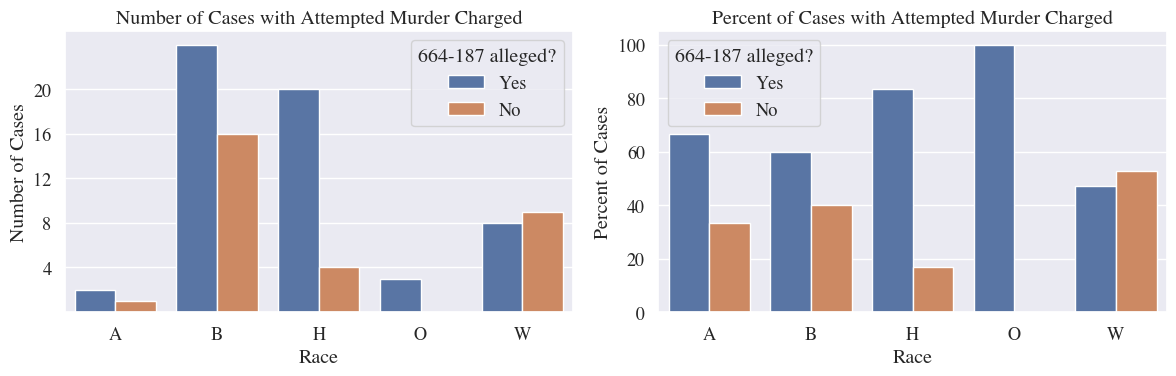

In [8]:
dist_charges = df.group_by(pl.col("664-187 alleged?", "Race")).len().with_columns(
    pl.when(pl.col("664-187 alleged?") == 1).then(pl.lit("Yes"))\
        .when(pl.col("664-187 alleged?") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('664-187 alleged?')).name.keep()
    ).sort("Race")
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(data=dist_charges, x="Race", hue="664-187 alleged?", hue_order=["Yes","No"], palette=custom_palette, y="len", ax=ax[0])
barplot.set_title("Number of Cases with Attempted Murder Charged")
barplot.set_yticks([4*i for i in range(1,6)])
barplot.set_ylabel("Number of Cases")
barplot1 = sns.barplot(data=get_pct(dist_charges,"664-187 alleged?"), x= "Race", hue="664-187 alleged?",hue_order=["Yes","No"], palette=custom_palette, y="pct", ax=ax[1])
barplot1.set_title("Percent of Cases with Attempted Murder Charged")
barplot1.set_ylabel("Percent of Cases")
plt.tight_layout()
plt.savefig("charges.pdf")
plt.show()

In [9]:
# dist_charges.to_pandas().set_index(["Race", "664-187 alleged?"])
display(dist_charges)

out_table = dist_charges.pivot("664-187 alleged?", index="Race", values="len")
#Add Non-Latino Section
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "H").select(pl.col("Yes","No").sum()).with_columns(pl.lit("Non-Latino").alias("Race"))],how="diagonal")
    
out_table = out_table.with_columns(pl.col("Race").replace(race_full_names)).fill_null(0)\
    .with_columns(
        pl.sum_horizontal(pl.col("Yes","No")).alias("Total"),
    ).with_columns(
         (pl.format("{}%",(pl.col("Yes") / pl.col("Total")).round(3).mul(10).mul(10))).alias("Risk")
    )
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "Non-Latino").select(pl.col("Yes","No", "Total").sum())\
                       .with_columns(pl.lit("Total").alias("Race"))],how="diagonal")\
    .rename({"No":"644/187 NOT Alleged","Yes":"644/187 Alleged"}).fill_null("---")
display(out_table)
out_table.select(["Race", "644/187 Alleged", "644/187 NOT Alleged", "Total", "Risk"]).to_pandas().to_latex("attempt_murder_alleged.tex", index=False)

664-187 alleged?,Race,len
str,str,u32
"""No""","""A""",1
"""Yes""","""A""",2
"""No""","""B""",16
"""Yes""","""B""",24
"""No""","""H""",4
"""Yes""","""H""",20
"""Yes""","""O""",3
"""No""","""W""",9
"""Yes""","""W""",8


Race,644/187 NOT Alleged,644/187 Alleged,Total,Risk
str,u32,u32,u32,str
"""Asian""",1,2,3,"""66.7%"""
"""Black""",16,24,40,"""60.0%"""
"""Latino""",4,20,24,"""83.3%"""
"""Other""",0,3,3,"""100.0%"""
"""White""",9,8,17,"""47.1%"""
"""Non-Latino""",26,37,63,"""58.69999999999999%"""
"""Total""",30,57,87,"""---"""


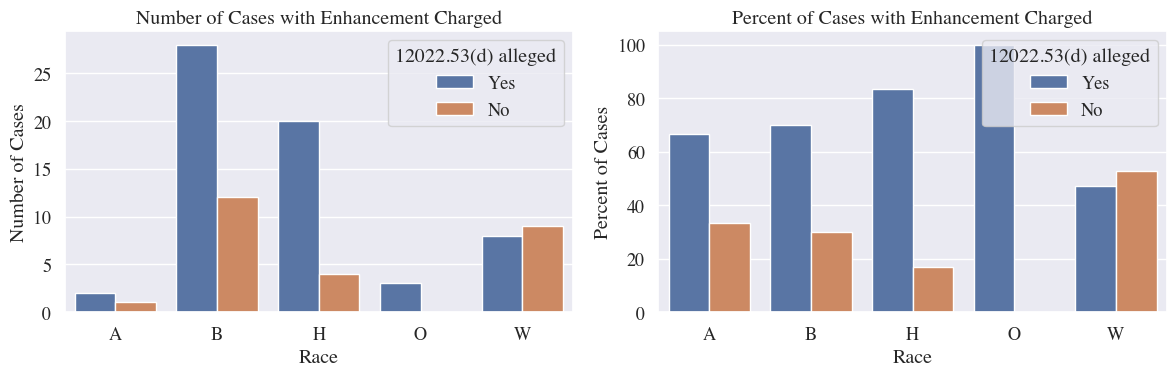

In [10]:
dist_charges = df.group_by(pl.col("12022.53(d) alleged", "Race")).len().with_columns(
    pl.when(pl.col("12022.53(d) alleged") == 1).then(pl.lit("Yes"))\
        .when(pl.col("12022.53(d) alleged") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('12022.53(d) alleged')).name.keep()
    ).sort("Race")
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(data=dist_charges, x= "Race", hue="12022.53(d) alleged",hue_order=["Yes","No"], palette=custom_palette, y="len", ax=ax[0])
barplot.set_title("Number of Cases with Enhancement Charged")
barplot.set_ylabel("Number of Cases")
barplot1 = sns.barplot(data=get_pct(dist_charges,"12022.53(d) alleged"), x= "Race", hue="12022.53(d) alleged",hue_order=["Yes","No"], palette=custom_palette, y="pct", ax=ax[1])
barplot1.set_title("Percent of Cases with Enhancement Charged")
barplot1.set_ylabel("Percent of Cases")
plt.tight_layout()
plt.savefig("enhancement.pdf")
plt.show()

In [11]:
dist_charges.to_pandas().set_index(["12022.53(d) alleged"])

,Race,len
12022.53(d) alleged,,
Yes,A,2
No,A,1
Yes,B,28
No,B,12
Yes,H,20
No,H,4
Yes,O,3
No,W,9
Yes,W,8


In [12]:
# dist_charges.to_pandas().set_index(["Race", "664-187 alleged?"])
display(dist_charges)

out_table = dist_charges.pivot("12022.53(d) alleged", index="Race", values="len")
#Add Non-Latino Section
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "H").select(pl.col("Yes","No").sum()).with_columns(pl.lit("Non-Latino").alias("Race"))],how="diagonal")
    
out_table = out_table.with_columns(pl.col("Race").replace(race_full_names)).fill_null(0)\
    .with_columns(
        pl.sum_horizontal(pl.col("Yes","No")).alias("Total"),
    ).with_columns(
         (pl.format("{}%",(pl.col("Yes") / pl.col("Total")).round(3).mul(10).mul(10))).alias("Risk")
    )
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "Non-Latino").select(pl.col("Yes","No", "Total").sum())\
                       .with_columns(pl.lit("Total").alias("Race"))],how="diagonal")\
    .rename({"No":"12022.53(d) NOT Alleged","Yes":"12022.53(d) Alleged"}).fill_null("---")
display(out_table)
out_table.select(["Race", "12022.53(d) Alleged", "12022.53(d) NOT Alleged", "Total", "Risk"]).to_pandas().to_latex("enhancement_alleged.tex", index=False)

12022.53(d) alleged,Race,len
str,str,u32
"""Yes""","""A""",2
"""No""","""A""",1
"""Yes""","""B""",28
"""No""","""B""",12
"""Yes""","""H""",20
"""No""","""H""",4
"""Yes""","""O""",3
"""No""","""W""",9
"""Yes""","""W""",8


Race,12022.53(d) Alleged,12022.53(d) NOT Alleged,Total,Risk
str,u32,u32,u32,str
"""Asian""",2,1,3,"""66.7%"""
"""Black""",28,12,40,"""70.0%"""
"""Latino""",20,4,24,"""83.3%"""
"""Other""",3,0,3,"""100.0%"""
"""White""",8,9,17,"""47.1%"""
"""Non-Latino""",41,22,63,"""65.1%"""
"""Total""",61,26,87,"""---"""


Prison,Race,len
str,str,u32
"""Yes""","""A""",1
"""No""","""A""",2
"""No""","""B""",12
"""Yes""","""B""",18
"""No""","""H""",2
"""Yes""","""H""",17
"""No""","""O""",3
"""Yes""","""W""",8
"""No""","""W""",8


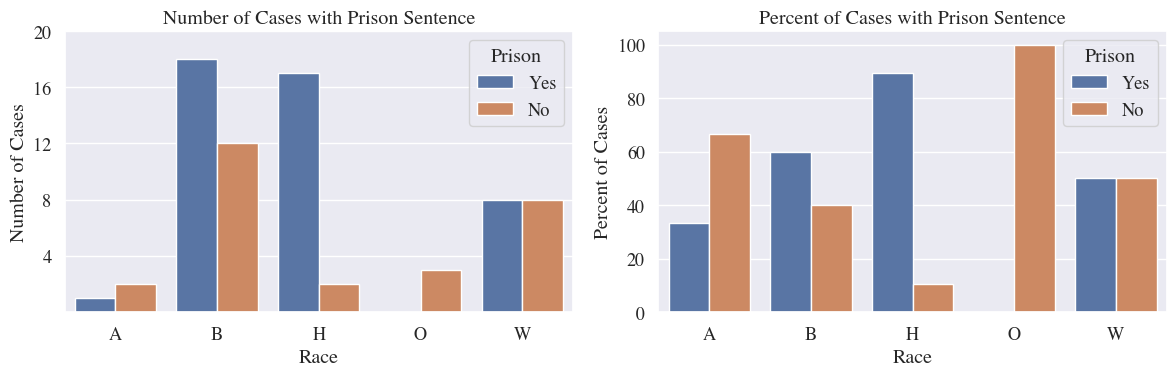

In [13]:
dist_charges = df.group_by(pl.col("Prison", "Race")).len().with_columns(
    pl.when(pl.col("Prison") == 1).then(pl.lit("Yes"))\
        .when(pl.col("Prison") == 0).then(pl.lit("No"))\
        #.when(pl.col("County Prison") == 1).then(pl.lit("No"))\
        .otherwise(pl.col('Prison')).name.keep()
    ).with_columns(
        pl.col("Prison").fill_null("Case Open")
    ).filter((pl.col("Prison") == "Yes") | (pl.col("Prison") == "No")).sort("Race")
display(dist_charges)
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(data=dist_charges, x= "Race", hue="Prison", hue_order=["Yes","No"], palette=custom_palette, y="len", ax=ax[0])
barplot.set_title("Number of Cases with Prison Sentence")
barplot.set_ylabel("Number of Cases")
barplot.set_yticks([4*i for i in range(1,6)])
barplot1 = sns.barplot(data=get_pct(dist_charges,"Prison"), x= "Race", hue="Prison",hue_order=["Yes","No"], palette=custom_palette, y="pct", ax=ax[1])
barplot1.set_title("Percent of Cases with Prison Sentence")
barplot1.set_ylabel("Percent of Cases")
plt.tight_layout()
plt.savefig("prison.pdf")
plt.show()

In [14]:
# dist_charges.to_pandas().set_index(["Race", "664-187 alleged?"])
display(dist_charges)

out_table = dist_charges.pivot("Prison", index="Race", values="len")
#Add Non-Latino Section
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "H").select(pl.col("Yes","No").sum()).with_columns(pl.lit("Non-Latino").alias("Race"))],how="diagonal")
    
out_table = out_table.with_columns(pl.col("Race").replace(race_full_names)).fill_null(0)\
    .with_columns(
        pl.sum_horizontal(pl.col("Yes","No")).alias("Total"),
    ).with_columns(
         (pl.format("{}%",(pl.col("Yes") / pl.col("Total")).round(3).mul(10).mul(10))).alias("Risk")
    )
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "Non-Latino").select(pl.col("Yes","No", "Total").sum())\
                       .with_columns(pl.lit("Total").alias("Race"))],how="diagonal")\
    .rename({"No":"No Prison","Yes":"Prison"}).fill_null("---")
display(out_table)
out_table.select(["Race", "Prison", "No Prison", "Total", "Risk"]).to_pandas().to_latex("prison.tex", index=False)

Prison,Race,len
str,str,u32
"""Yes""","""A""",1
"""No""","""A""",2
"""No""","""B""",12
"""Yes""","""B""",18
"""No""","""H""",2
"""Yes""","""H""",17
"""No""","""O""",3
"""Yes""","""W""",8
"""No""","""W""",8


Race,Prison,No Prison,Total,Risk
str,u32,u32,u32,str
"""Asian""",1,2,3,"""33.3%"""
"""Black""",18,12,30,"""60.0%"""
"""Latino""",17,2,19,"""89.5%"""
"""Other""",0,3,3,"""0.0%"""
"""White""",8,8,16,"""50.0%"""
"""Non-Latino""",27,25,52,"""51.900000000000006%"""
"""Total""",44,27,71,"""---"""


State prison Prison?,Race,len
str,str,u32
"""Yes""","""A""",1
"""Yes""","""B""",7
"""Yes""","""H""",8


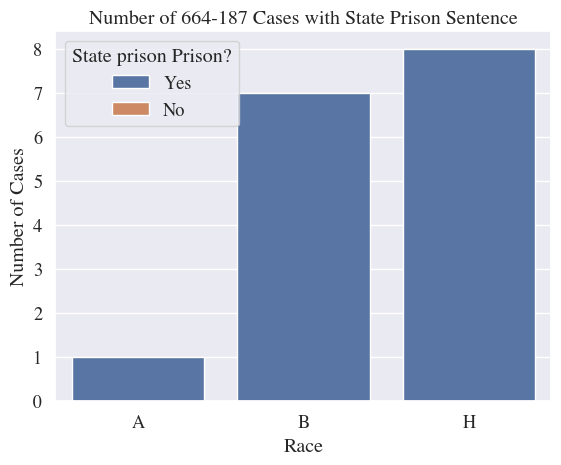

In [15]:
dist_charges = df.filter((pl.col("Convicted of 664-187? 0 = no, 1 = yes") == 1))\
.group_by(pl.col("State prison Prison?", "Race")).len().with_columns(
    pl.when(pl.col("State prison Prison?") == 1).then(pl.lit("Yes"))\
        .when(pl.col("State prison Prison?") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('State prison Prison?')).name.keep()
    ).with_columns(
        pl.col("State prison Prison?").fill_null("Case Open")
    ).filter((pl.col("State prison Prison?") == "Yes") | (pl.col("State prison Prison?") == "No"))
display(dist_charges)
barplot = sns.barplot(data=dist_charges, x= "Race", hue="State prison Prison?", hue_order=["Yes","No"], palette=custom_palette, y="len")
barplot.set_title("Number of 664-187 Cases with State Prison Sentence")
barplot.set_ylabel("Number of Cases")
plt.show()

In [16]:
# dist_chareges_df = dist_charges.to_pandas()
# multi_ind = pd.multi
# dist_charges.set_index()

State prison Prison?,Race,len
str,str,u32
"""Yes""","""W""",6
"""No""","""B""",2
"""Yes""","""H""",7
"""Yes""","""A""",1
"""No""","""H""",1
"""No""","""A""",1
"""No""","""W""",1
"""Yes""","""B""",11


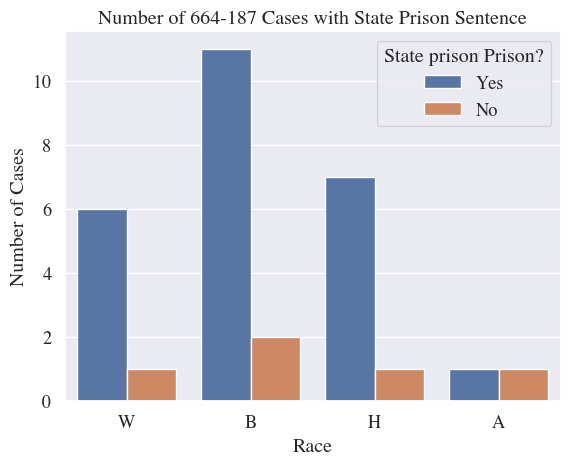

In [17]:
dist_charges = df.filter((pl.col("245(a)(2), (a)(3), or(b)  gun conviction") == "1"))\
.group_by(pl.col("State prison Prison?", "Race")).len().with_columns(
    pl.when(pl.col("State prison Prison?") == 1).then(pl.lit("Yes"))\
        .when(pl.col("State prison Prison?") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('State prison Prison?')).name.keep()
    ).with_columns(
        pl.col("State prison Prison?").fill_null("Case Open")
    ).filter((pl.col("State prison Prison?") == "Yes") | (pl.col("State prison Prison?") == "No"))
display(dist_charges)
barplot = sns.barplot(data=dist_charges, x= "Race", hue="State prison Prison?", hue_order=["Yes","No"], palette=custom_palette, y="len")
barplot.set_title("Number of 664-187 Cases with State Prison Sentence")
barplot.set_ylabel("Number of Cases")
plt.show()

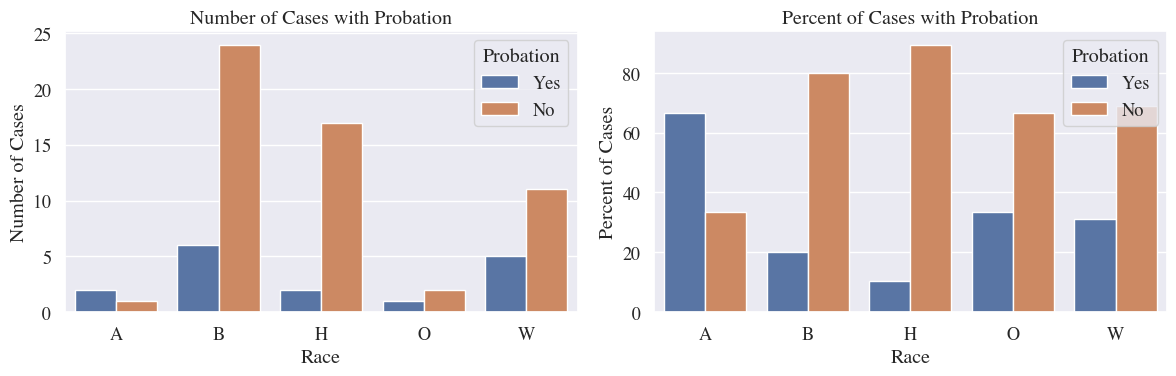

In [18]:
dist_charges = df.group_by(pl.col("Probation", "Race")).len().with_columns(
    pl.when(pl.col("Probation") == 1).then(pl.lit("Yes"))\
        .when(pl.col("Probation") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('Probation')).name.keep()
    ).with_columns(
        pl.col("Probation").fill_null("Case Open")
    ).filter((pl.col("Probation") == "Yes") | (pl.col("Probation") == "No")).sort("Race")
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(data=dist_charges, x= "Race", hue="Probation",hue_order=["Yes","No"], palette=custom_palette, y="len",ax=ax[0])
barplot.set_title("Number of Cases with Probation")
barplot.set_ylabel("Number of Cases")
barplot1 = sns.barplot(data=get_pct(dist_charges,"Probation"), x= "Race", hue="Probation",hue_order=["Yes","No"], palette=custom_palette, y="pct", ax=ax[1])
barplot1.set_title("Percent of Cases with Probation")
barplot1.set_ylabel("Percent of Cases")
plt.tight_layout()
plt.savefig("probation.pdf")
plt.show()

In [19]:
out_table = dist_charges.pivot("Probation", index="Race", values="len")
#Add Non-Latino Section
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "H").select(pl.col("Yes","No").sum()).with_columns(pl.lit("Non-Latino").alias("Race"))],how="diagonal")
    
out_table = out_table.with_columns(pl.col("Race").replace(race_full_names)).fill_null(0)\
    .with_columns(
        pl.sum_horizontal(pl.col("Yes","No")).alias("Total"),
    ).with_columns(
         (pl.format("{}%",(pl.col("No") / pl.col("Total")).round(3).mul(10).mul(10))).alias("Risk")
    )
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "Non-Latino").select(pl.col("Yes","No", "Total").sum())\
                       .with_columns(pl.lit("Total").alias("Race"))],how="diagonal")\
    .rename({"No":"No Probation","Yes":"Probation"}).fill_null("---")
display(out_table)
out_table.select(["Race", "No Probation", "Probation", "Total", "Risk"]).to_pandas().to_latex("probation.tex", index=False)

Race,Probation,No Probation,Total,Risk
str,u32,u32,u32,str
"""Asian""",2,1,3,"""33.3%"""
"""Black""",6,24,30,"""80.0%"""
"""Latino""",2,17,19,"""89.5%"""
"""Other""",1,2,3,"""66.7%"""
"""White""",5,11,16,"""68.79999999999998%"""
"""Non-Latino""",14,38,52,"""73.1%"""
"""Total""",16,55,71,"""---"""


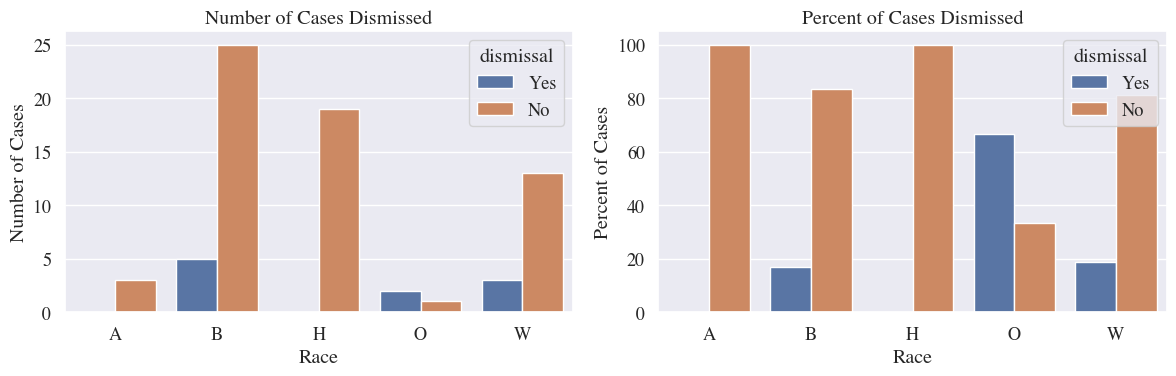

In [20]:
dist_charges = df.group_by(pl.col("Dismissal?", "Race")).len().with_columns(
    pl.when(pl.col("Dismissal?") == 1).then(pl.lit("Yes"))\
        .when(pl.col("Dismissal?") == 0).then(pl.lit("No"))\
        .otherwise(pl.col('Dismissal?')).name.keep()
    ).with_columns(
        pl.col("Dismissal?").fill_null("Case Open")
    ).filter((pl.col("Dismissal?") == "Yes") | (pl.col("Dismissal?") == "No")).sort("Race")
fig, ax = plt.subplots(1,2, figsize=(12,4))
barplot = sns.barplot(data=dist_charges.rename({"Dismissal?": "dismissal"}), x= "Race", hue="dismissal", hue_order=["Yes","No"], palette=custom_palette, y="len", ax=ax[0])
barplot.set_title("Number of Cases Dismissed")
barplot.set_ylabel("Number of Cases")
barplot1 = sns.barplot(data=get_pct(dist_charges, "Dismissal?").rename({"Dismissal?": "dismissal"}), x= "Race", hue="dismissal", hue_order=["Yes","No"], palette=custom_palette, y="pct", ax=ax[1])
barplot1.set_title("Percent of Cases Dismissed")
barplot1.set_ylabel("Percent of Cases")
plt.tight_layout()
plt.savefig("dismissed.pdf")

In [21]:
out_table = dist_charges.pivot("Dismissal?", index="Race", values="len")
#Add Non-Latino Section
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "H").select(pl.col("Yes","No").sum()).with_columns(pl.lit("Non-Latino").alias("Race"))],how="diagonal")
    
out_table = out_table.with_columns(pl.col("Race").replace(race_full_names)).fill_null(0)\
    .with_columns(
        pl.sum_horizontal(pl.col("Yes","No")).alias("Total"),
    ).with_columns(
         (pl.format("{}%",(pl.col("No") / pl.col("Total")).round(3).mul(10).mul(10))).alias("Risk")
    )
out_table = pl.concat([out_table, out_table.filter(pl.col("Race") != "Non-Latino").select(pl.col("Yes","No", "Total").sum())\
                       .with_columns(pl.lit("Total").alias("Race"))],how="diagonal")\
    .rename({"No":"No Dismissal","Yes":"Dismissal"}).fill_null("---")
display(out_table)
out_table.select(["Race", "No Dismissal", "Dismissal", "Total", "Risk"]).to_pandas().to_latex("dismissal.tex", index=False)

Race,No Dismissal,Dismissal,Total,Risk
str,u32,u32,u32,str
"""Asian""",3,0,3,"""100.0%"""
"""Black""",25,5,30,"""83.3%"""
"""Latino""",19,0,19,"""100.0%"""
"""Other""",1,2,3,"""33.3%"""
"""White""",13,3,16,"""81.29999999999998%"""
"""Non-Latino""",42,10,52,"""80.8%"""
"""Total""",61,10,71,"""---"""


# Prison Sentences including 0 month sentences

Race,Mean Prison Sentence,Median Prison Sentence,Total Cases with Prison Sentences
str,f64,f64,u32
"""A""",60.0,0.0,3
"""B""",95.2,92.0,30
"""H""",113.578947,120.0,19
"""O""",0.0,0.0,3
"""W""",41.25,8.0,16


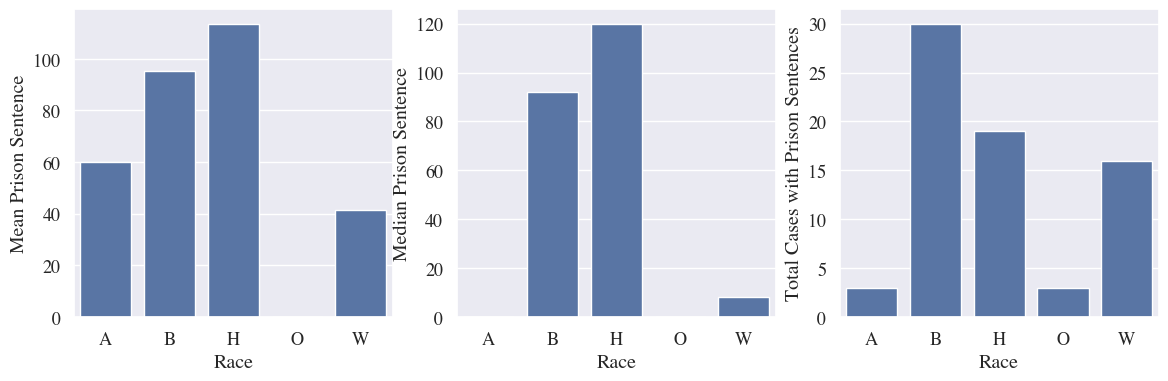

In [22]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null())\
    .group_by(pl.col("Race"))\
    .agg(
        (pl.col("Prison in months").mean().alias("Mean Prison Sentence")),
        (pl.col("Prison in months").median().alias("Median Prison Sentence")),
        (pl.col("Prison in months").count().alias("Total Cases with Prison Sentences"))
        ).sort("Race")
display(dist_charges)
total = dist_charges.to_pandas().round(3)[["Race", "Mean Prison Sentence", "Median Prison Sentence"]]
#print(dist_charges.to_pandas().round(3)[["Mean Prison Sentence",	"Median Prison Sentence"]].to_latex())
fig, axs = plt.subplots(1, 3, figsize=(14,4))
sns.barplot(data=dist_charges, x= "Race",y="Mean Prison Sentence",ax=axs[0])
sns.barplot(data=dist_charges, x= "Race",y="Median Prison Sentence",ax=axs[1])
sns.barplot(data=dist_charges, x= "Race",y="Total Cases with Prison Sentences",ax=axs[2])
plt.show()

In [23]:
(114-41)/41

1.7804878048780488

In [24]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null())
print(dist_charges.select(pl.mean("Prison in months")))
print(dist_charges.select(pl.median("Prison in months")))

shape: (1, 1)
┌──────────────────┐
│ Prison in months │
│ ---              │
│ f64              │
╞══════════════════╡
│ 82.450704        │
└──────────────────┘
shape: (1, 1)
┌──────────────────┐
│ Prison in months │
│ ---              │
│ f64              │
╞══════════════════╡
│ 72.0             │
└──────────────────┘


Race,Mean Prison Sentence,Median Prison Sentence,Total Cases with Prison Sentences
str,f64,f64,u32
"""A""",180.0,180.0,1
"""B""",147.333333,150.0,18
"""H""",123.375,120.0,16
"""W""",68.0,28.0,6


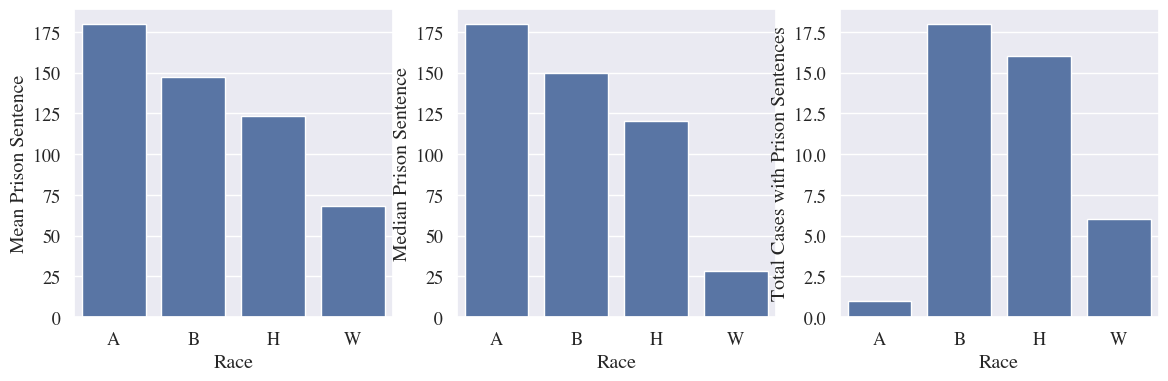

In [25]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null(),
            pl.col("Prison in months") > 0,
            pl.col("If convicted, 1=plea, 2=JT\n0 = dismissal or pending\n3 = acquittal") == 1)\
    .group_by(pl.col("Race"))\
    .agg(
        (pl.col("Prison in months").mean().alias("Mean Prison Sentence")),
        (pl.col("Prison in months").median().alias("Median Prison Sentence")),
        (pl.col("Prison in months").count().alias("Total Cases with Prison Sentences"))
        ).sort("Race")
display(dist_charges)
prison_true = dist_charges.to_pandas().round(3)[["Race", "Mean Prison Sentence", "Median Prison Sentence"]]
#print(dist_charges.to_pandas().round(3)[["Mean Prison Sentence",	"Median Prison Sentence"]].to_latex())
fig, axs = plt.subplots(1, 3, figsize=(14,4))
sns.barplot(data=dist_charges, x= "Race",y="Mean Prison Sentence",ax=axs[0])
sns.barplot(data=dist_charges, x= "Race",y="Median Prison Sentence",ax=axs[1])
sns.barplot(data=dist_charges, x= "Race",y="Total Cases with Prison Sentences",ax=axs[2])
plt.show()

In [26]:
(123-68)/68

0.8088235294117647

In [27]:
print(pd.merge(total, prison_true, on="Race", how="inner").to_latex())

\begin{tabular}{llrrrr}
\toprule
 & Race & Mean Prison Sentence_x & Median Prison Sentence_x & Mean Prison Sentence_y & Median Prison Sentence_y \\
\midrule
0 & A & 60.000000 & 0.000000 & 180.000000 & 180.000000 \\
1 & B & 95.200000 & 92.000000 & 147.333000 & 150.000000 \\
2 & H & 113.579000 & 120.000000 & 123.375000 & 120.000000 \\
3 & W & 41.250000 & 8.000000 & 68.000000 & 28.000000 \\
\bottomrule
\end{tabular}



In [28]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null(),
            pl.col("Prison in months") > 0,
            pl.col("If convicted, 1=plea, 2=JT\n0 = dismissal or pending\n3 = acquittal") == 1)
print(dist_charges.select(pl.mean("Prison in months")))
print(dist_charges.select(pl.median("Prison in months")))

shape: (1, 1)
┌──────────────────┐
│ Prison in months │
│ ---              │
│ f64              │
╞══════════════════╡
│ 127.170732       │
└──────────────────┘
shape: (1, 1)
┌──────────────────┐
│ Prison in months │
│ ---              │
│ f64              │
╞══════════════════╡
│ 120.0            │
└──────────────────┘


# Extra Exploratory Analysis

/var/folders/cn/5p5n6ztx4310_zhlpq83ldym0000gn/T/ipykernel_39292/2213169965.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(data=dist_charges, x="Prison in months", hue="Race", kind="kde")


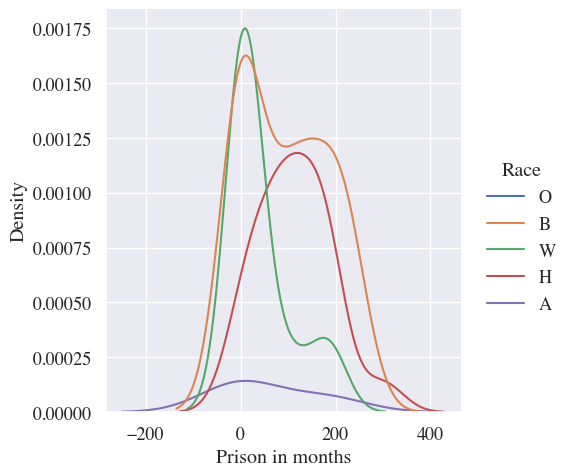

In [29]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null())
sns.displot(data=dist_charges, x="Prison in months", hue="Race", kind="kde")

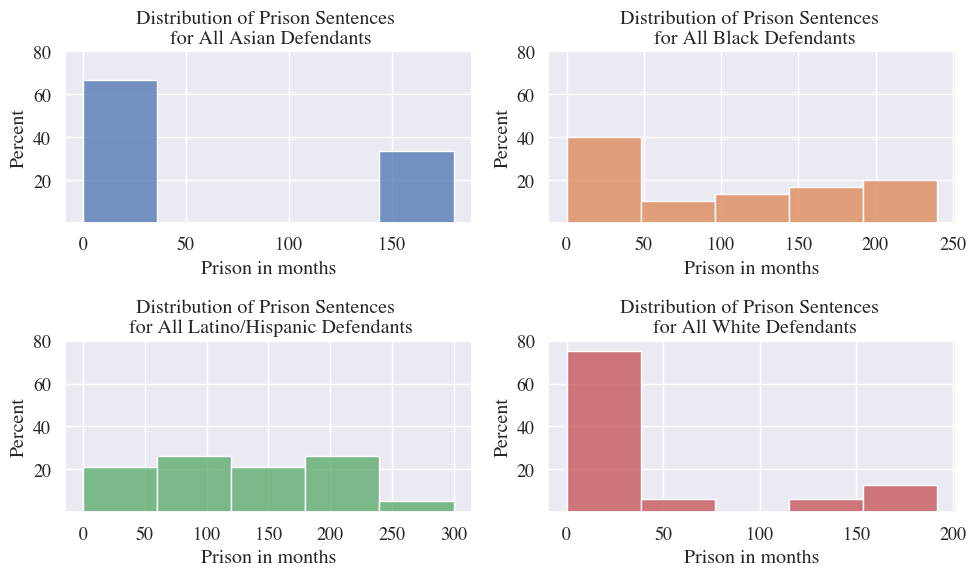

In [30]:
dist_charges = df.filter((pl.col("Open  = 0; Closed =1") == 1))\
    .filter(pl.col("Prison in months").is_not_null()).sort("Race")
fig, axs = plt.subplots(2, 2, figsize=(10,6))
i=0
j = 0
col = 0
races = {"H": "Latino/Hispanic", "W": "White", "A":"Asian", "B":"Black"}
colors = sns.color_palette()
for race in dist_charges["Race"].unique().sort():
    if race!= "O":
        sns.histplot(data=dist_charges.filter((pl.col("Race") == race)), x="Prison in months", ax= axs[i,j], color=colors[col], stat="percent", bins=5)
        axs[i, j].set_title(f"Distribution of Prison Sentences \n for All {races[race]} Defendants")
        axs[i, j].set_yticks([20*i for i in range(1,5)])
        j += 1
        col += 1
        if (j > 1):
            j = 0
            i += 1
plt.tight_layout()
plt.savefig("sentence_dist_total.pdf")